---
# 🟠 PARTIE II — CNN + Dérivés  <a id='partie-ii'></a>

**Thème :** Classification d'images avec CNN et ses architectures dérivées.

**Dataset :** *MNIST* — 70 000 images 28×28, 10 classes.

**Plan :**
1. Théorie — CNN, padding, stride, pooling, canaux multiples, conv 1×1
2. Calculs manuels
3. Implémentation manuelle : corrélation croisée, max-pooling, average-pooling
4. Canaux multiples
5. Comparaison manuelle vs PyTorch
6. CNN de base (LeNet)
7. CNN dérivés : AlexNet simplifié, VGG simplifié
8. Étude padding / stride / pooling / filtres / conv 1×1
9. Visualisation et interprétation des feature maps
10. Comparaison MLP vs CNN vs dérivés
11. Question de synthèse

---
##  Étape II.1 — Implémentation manuelle

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


In [2]:
# ================================================================
# CONVOLUTION 2D, MAX-POOLING, AVERAGE-POOLING MANUELS
# Repris du TP cnn_from_scratch_numpy.py
# ================================================================
def convolution2d(x, k, stride=1, padding=0):
    """Corrélation croisée 2D manuelle"""
    if padding > 0:
        x = np.pad(x, ((padding, padding), (padding, padding)),
                   mode='constant', constant_values=0)
    h, w   = x.shape
    kh, kw = k.shape
    out_h  = ((h - kh) // stride) + 1
    out_w  = ((w - kw) // stride) + 1
    out    = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i,j] = np.sum(x[i*stride:i*stride+kh, j*stride:j*stride+kw] * k)
    return out

def max_pooling(x, size=2, stride=2):
    """Max-pooling manuel"""
    h, w  = x.shape
    out_h = ((h - size) // stride) + 1
    out_w = ((w - size) // stride) + 1
    out   = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i,j] = np.max(x[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

def average_pooling(x, size=2, stride=2):
    """Average-pooling manuel"""
    h, w  = x.shape
    out_h = ((h - size) // stride) + 1
    out_w = ((w - size) // stride) + 1
    out   = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i,j] = np.mean(x[i*stride:i*stride+size, j*stride:j*stride+size])
    return out


# Test
image  = np.array([[1,2,0,1],[3,1,2,2],[0,1,3,1],[2,2,1,0]], dtype=float)
kernel = np.array([[1,0],[0,1]], dtype=float)
conv   = convolution2d(image, kernel)
print('Convolution manuelle :\n', conv)

sample = np.array([[3,1,2,4],[1,5,2,3],[4,2,1,3],[2,1,3,2]], dtype=float)
print('\nMax-pooling     :\n', max_pooling(sample, 2, 2))
print('Average-pooling :\n', average_pooling(sample, 2, 2))

Convolution manuelle :
 [[2. 4. 2.]
 [4. 4. 3.]
 [2. 2. 3.]]

Max-pooling     :
 [[5. 4.]
 [4. 3.]]
Average-pooling :
 [[2.5  2.75]
 [2.25 2.25]]


---
##  Étape II.2 — Canaux multiples

Entrée : (3, 4, 4) | 2 filtres → 2 feature maps : (3, 3)
Paramètres (2 filtres, C_in=3, k=2x2) : 24 (sans biais)


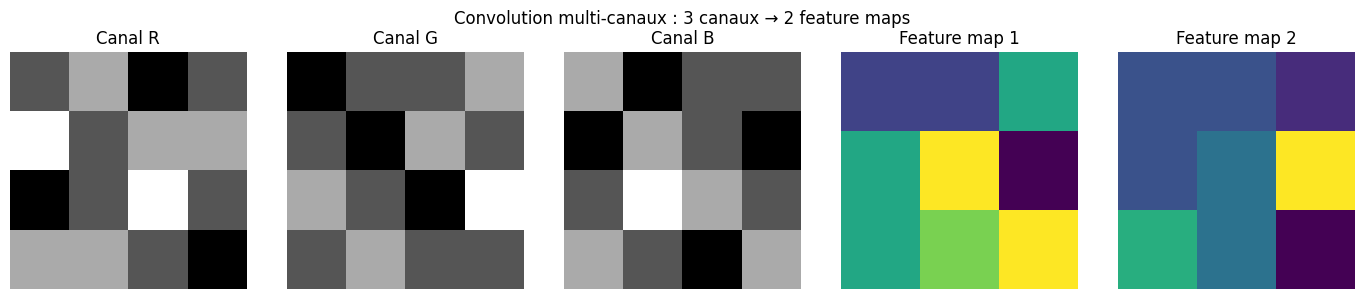

In [3]:
# ================================================================
# CONVOLUTION MULTI-CANAUX
# ================================================================
def convolution2d_multicanaux(X, K, stride=1, padding=0):
    """X : (C_in, H, W) | K : (C_in, kH, kW) → une feature map"""
    sortie = np.zeros_like(convolution2d(X[0], K[0], stride, padding))
    for c in range(X.shape[0]):
        sortie += convolution2d(X[c], K[c], stride, padding)
    return sortie


X_rgb = np.array([
    [[1,2,0,1],[3,1,2,2],[0,1,3,1],[2,2,1,0]],
    [[0,1,1,2],[1,0,2,1],[2,1,0,3],[1,2,1,1]],
    [[2,0,1,1],[0,2,1,0],[1,3,2,1],[2,1,0,2]],
], dtype=float)
K1 = np.array([[[1,0],[0,1]], [[0,1],[1,0]], [[1,1],[0,0]]], dtype=float)
K2 = np.array([[[0,1],[1,0]], [[1,0],[0,1]], [[0,0],[1,1]]], dtype=float)

fm1 = convolution2d_multicanaux(X_rgb, K1)
fm2 = convolution2d_multicanaux(X_rgb, K2)
print(f'Entrée : {X_rgb.shape} | 2 filtres → 2 feature maps : {fm1.shape}')
print(f'Paramètres (2 filtres, C_in=3, k=2x2) : {2*3*2*2} (sans biais)')

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, (canal, titre) in enumerate(zip(X_rgb, ['Canal R','Canal G','Canal B'])):
    axes[i].imshow(canal, cmap='gray'); axes[i].set_title(titre); axes[i].axis('off')
axes[3].imshow(fm1, cmap='viridis'); axes[3].set_title('Feature map 1'); axes[3].axis('off')
axes[4].imshow(fm2, cmap='viridis'); axes[4].set_title('Feature map 2'); axes[4].axis('off')
plt.suptitle('Convolution multi-canaux : 3 canaux → 2 feature maps')
plt.tight_layout(); plt.show()

---
##  Étape II.3 — Comparaison manuelle vs PyTorch

In [4]:
# ================================================================
# COMPARAISON MANUELLE vs PYTORCH
# ================================================================
image_t  = torch.tensor(image,  dtype=torch.float32).unsqueeze(0).unsqueeze(0)
kernel_t = torch.tensor(kernel, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
conv_layer = nn.Conv2d(1, 1, kernel_size=2, stride=1, padding=0, bias=False)
conv_layer.weight.data = kernel_t
with torch.no_grad():
    conv_pytorch = conv_layer(image_t).squeeze().numpy()
print('Manuel  :\n', conv)
print('PyTorch :\n', conv_pytorch)
print('Différence max :', np.max(np.abs(conv - conv_pytorch)), '✅')

sample_t = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    mp_pt = nn.MaxPool2d(2, stride=2)(sample_t).squeeze().numpy()
    ap_pt = nn.AvgPool2d(2, stride=2)(sample_t).squeeze().numpy()
print('\nMax-pooling manuel  :\n', max_pooling(sample, 2, 2))
print('Max-pooling PyTorch :\n',   mp_pt)
print('\nAvg-pooling manuel  :\n', average_pooling(sample, 2, 2))
print('Avg-pooling PyTorch :\n',   ap_pt)

Manuel  :
 [[2. 4. 2.]
 [4. 4. 3.]
 [2. 2. 3.]]
PyTorch :
 [[2. 4. 2.]
 [4. 4. 3.]
 [2. 2. 3.]]
Différence max : 0.0 ✅

Max-pooling manuel  :
 [[5. 4.]
 [4. 3.]]
Max-pooling PyTorch :
 [[5. 4.]
 [4. 3.]]

Avg-pooling manuel  :
 [[2.5  2.75]
 [2.25 2.25]]
Avg-pooling PyTorch :
 [[2.5  2.75]
 [2.25 2.25]]


---
##  Étape II.4 — Chargement MNIST

100.0%
100.0%
100.0%
100.0%


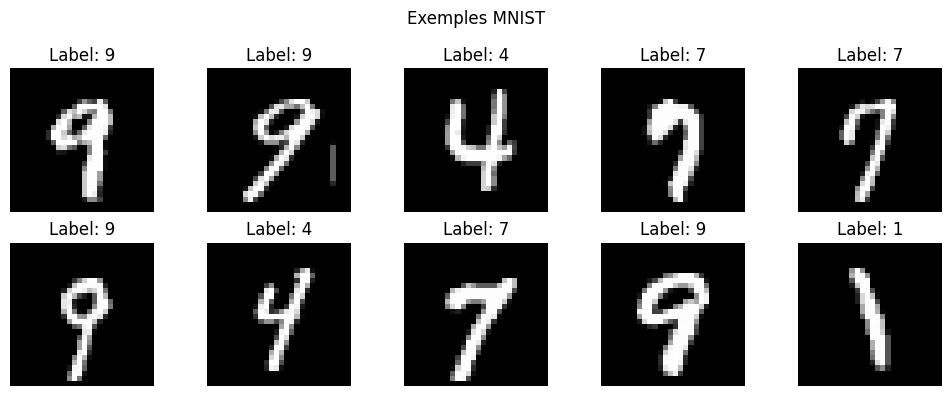

Train : 60000 | Test : 10000 | Device : cpu


In [5]:
# ================================================================
# DATASET MNIST
# ================================================================
transform   = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])
trainset    = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
testset     = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = DataLoader(testset,  batch_size=64, shuffle=False)

images, labels = next(iter(trainloader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}'); ax.axis('off')
plt.suptitle('Exemples MNIST'); plt.tight_layout(); plt.show()
print(f'Train : {len(trainset)} | Test : {len(testset)} | Device : {device}')

---
##  Étape II.5 — Architectures CNN : LeNet, AlexNet simplifié, VGG simplifié

### LeNet
Architecture originale : 2 couches conv + 3 couches FC. Simple et efficace pour MNIST.

### AlexNet simplifié
Adapté pour MNIST. Idées clés : **ReLU**, **Dropout**, **BatchNorm**, plus de filtres.

### VGG simplifié
Idée principale : empiler plusieurs convolutions 3×3 avant chaque pooling → capture des motifs plus complexes avec moins de paramètres qu'un grand kernel.

In [6]:
# ================================================================
# LENET — architecture de base
# ================================================================
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 6,  kernel_size=5, padding=2)
        self.conv2   = nn.Conv2d(6, 16, kernel_size=5)
        self.pool    = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(16*5*5, 120)
        self.fc2     = nn.Linear(120, 84)
        self.fc3     = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


# ================================================================
# ALEXNET SIMPLIFIÉ — adapté pour MNIST 28x28
# Ajout : BatchNorm + Dropout par rapport à LeNet
# ================================================================
class AlexNetSimple(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 7x7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 7x7
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ================================================================
# VGG SIMPLIFIÉ — blocs de conv 3x3 empilées
# ================================================================
class VGGSimple(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1 : 2 conv 3x3
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # 28x28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 14x14
            # Bloc 2 : 2 conv 3x3
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14x14
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 14x14
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                            # 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Afficher les architectures
for nom, modele in [('LeNet', LeNet()), ('AlexNet simplifié', AlexNetSimple()), ('VGG simplifié', VGGSimple())]:
    n_params = sum(p.numel() for p in modele.parameters())
    print(f'=== {nom} === ({n_params:,} paramètres)')
    print(modele)
    print()

=== LeNet === (61,706 paramètres)
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

=== AlexNet simplifié === (1,701,322 paramètres)
AlexNetSimple(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

---
##  Étape II.6 — Entraînement et comparaison des 3 architectures

In [7]:
# ================================================================
# FONCTION D'ÉVALUATION
# ================================================================
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            _, predicted   = torch.max(model(images), 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# ================================================================
# ENTRAÎNEMENT DES 3 ARCHITECTURES CNN
# ================================================================
architectures_cnn = [
    ('LeNet',             LeNet()),
    ('AlexNet simplifié', AlexNetSimple()),
    ('VGG simplifié',     VGGSimple())
]

resultats_cnn = {}
num_epochs    = 5

for nom, modele in architectures_cnn:
    print(f'\n=== Entraînement : {nom} ===')
    modele    = modele.to(device)
    optimizer = optim.Adam(modele.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    train_losses, test_accs = [], []

    for epoch in range(num_epochs):
        modele.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = modele(images)
            loss    = criterion(outputs, labels)
            loss.backward(); optimizer.step()
            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        test_acc   = evaluate_accuracy(modele, testloader, device)
        train_losses.append(epoch_loss)
        test_accs.append(test_acc)
        print(f'  Epoch [{epoch+1}/{num_epochs}]  Loss={epoch_loss:.4f}  Test={test_acc:.2f}%')

    # Sauvegarde
    torch.save(modele.state_dict(), f'{nom.replace(" ","_")}.pth')
    resultats_cnn[nom] = {
        'losses'  : train_losses,
        'test_accs': test_accs,
        'test_acc': test_accs[-1],
        'params'  : sum(p.numel() for p in modele.parameters()),
        'model'   : modele
    }
    print(f'  ✅ Test Accuracy finale : {test_accs[-1]:.2f}%')


=== Entraînement : LeNet ===
  Epoch [1/5]  Loss=0.2586  Test=97.97%
  Epoch [2/5]  Loss=0.0682  Test=98.35%
  Epoch [3/5]  Loss=0.0502  Test=98.51%
  Epoch [4/5]  Loss=0.0410  Test=98.56%
  Epoch [5/5]  Loss=0.0339  Test=98.89%
  ✅ Test Accuracy finale : 98.89%

=== Entraînement : AlexNet simplifié ===
  Epoch [1/5]  Loss=0.1357  Test=98.91%
  Epoch [2/5]  Loss=0.0517  Test=99.22%
  Epoch [3/5]  Loss=0.0401  Test=99.06%
  Epoch [4/5]  Loss=0.0328  Test=99.21%
  Epoch [5/5]  Loss=0.0285  Test=99.30%
  ✅ Test Accuracy finale : 99.30%

=== Entraînement : VGG simplifié ===
  Epoch [1/5]  Loss=0.1759  Test=98.59%
  Epoch [2/5]  Loss=0.0603  Test=99.04%
  Epoch [3/5]  Loss=0.0415  Test=99.03%
  Epoch [4/5]  Loss=0.0352  Test=99.21%
  Epoch [5/5]  Loss=0.0282  Test=99.28%
  ✅ Test Accuracy finale : 99.28%


=== Tableau comparatif des architectures CNN ===
Architecture           Paramètres     Test Accuracy
----------------------------------------------------
LeNet                  61706,,,,,,,,, 98.89%
AlexNet simplifié      1701322,,,,,,, 99.30%
VGG simplifié          870634,,,,,,,, 99.28%


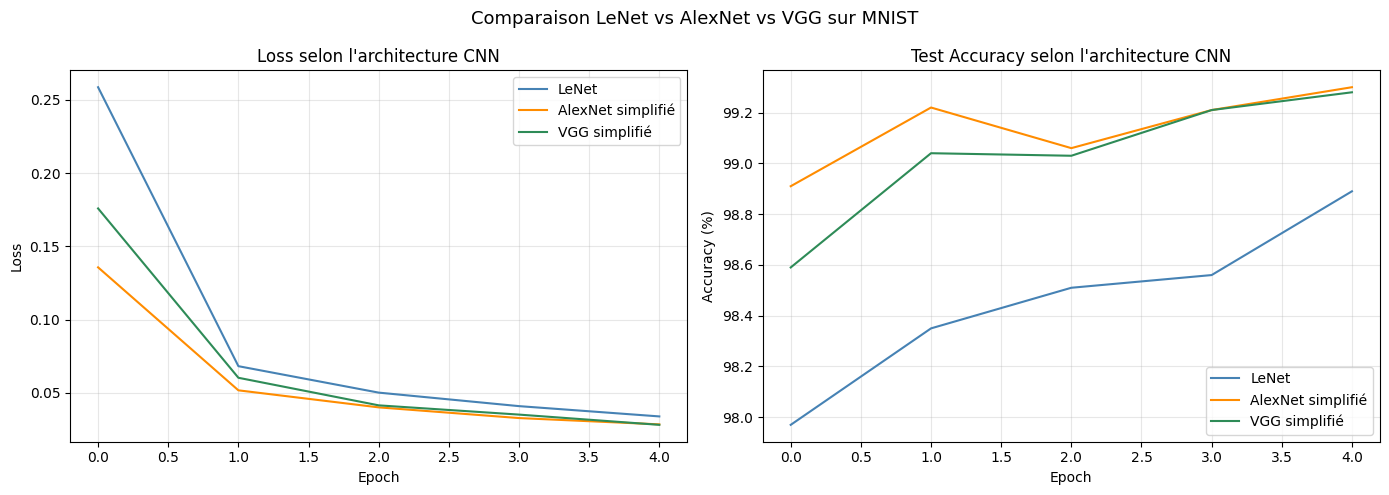

In [8]:
# ================================================================
# TABLEAU COMPARATIF DES 3 ARCHITECTURES CNN
# ================================================================
print('=== Tableau comparatif des architectures CNN ===')
print(f'{"Architecture":<22} {"Paramètres":<14} {"Test Accuracy"}')
print('-' * 52)
for nom, res in resultats_cnn.items():
    print(f'{nom:<22} {res["params"]:,<14} {res["test_acc"]:.2f}%')

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
couleurs = {'LeNet': 'steelblue', 'AlexNet simplifié': 'darkorange', 'VGG simplifié': 'seagreen'}
for nom, res in resultats_cnn.items():
    ax1.plot(res['losses'],   label=nom, color=couleurs[nom])
    ax2.plot(res['test_accs'],label=nom, color=couleurs[nom])

ax1.set_title('Loss selon l\'architecture CNN')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title('Test Accuracy selon l\'architecture CNN')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Comparaison LeNet vs AlexNet vs VGG sur MNIST', fontsize=13)
plt.tight_layout(); plt.show()

---
## 🔬 Étape II.7 — Étude padding / stride / pooling / filtres / conv 1×1

In [9]:
# ================================================================
# IMPACT DU PADDING ET DU STRIDE — calculs
# ================================================================
print('Impact du padding et du stride (kernel=5, entrée=28x28) :')
print(f'{"Config":<30} {"Taille sortie"}')
print('-' * 45)
for p, s in [(0,1),(1,1),(2,1),(0,2),(2,2)]:
    out = (28 - 5 + 2*p) // s + 1
    print(f'padding={p}, stride={s}  →  {out}x{out}')

print('\nComparaison max-pooling vs average-pooling :')
print('Max-pooling     :\n', max_pooling(sample, 2, 2))
print('Average-pooling :\n', average_pooling(sample, 2, 2))
print('\n→ Max-pooling : conserve valeurs dominantes')
print('→ Average-pooling : lisse les valeurs')

Impact du padding et du stride (kernel=5, entrée=28x28) :
Config                         Taille sortie
---------------------------------------------
padding=0, stride=1  →  24x24
padding=1, stride=1  →  26x26
padding=2, stride=1  →  28x28
padding=0, stride=2  →  12x12
padding=2, stride=2  →  14x14

Comparaison max-pooling vs average-pooling :
Max-pooling     :
 [[5. 4.]
 [4. 3.]]
Average-pooling :
 [[2.5  2.75]
 [2.25 2.25]]

→ Max-pooling : conserve valeurs dominantes
→ Average-pooling : lisse les valeurs


In [10]:
# ================================================================
# ÉTUDE DE LA CONVOLUTION 1x1
# ================================================================
class LeNetConv1x1(nn.Module):
    """LeNet avec convolution 1x1 après conv2 pour réduire les canaux"""
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 6,  kernel_size=5, padding=2)
        self.conv2   = nn.Conv2d(6, 16, kernel_size=5)
        self.conv1x1 = nn.Conv2d(16, 8, kernel_size=1)  # 16 → 8 canaux
        self.pool    = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(8*5*5, 120)
        self.fc2     = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.relu(self.conv1x1(x))  # compression 16 → 8 canaux
        x = self.flatten(x)
        return self.fc2(torch.relu(self.fc1(x)))


print('Comparaison LeNet vs LeNet+conv1x1 :')
lenet_base  = LeNet().to(device)
lenet_1x1   = LeNetConv1x1().to(device)
print(f'  LeNet base    : {sum(p.numel() for p in lenet_base.parameters()):,} paramètres')
print(f'  LeNet + 1x1   : {sum(p.numel() for p in lenet_1x1.parameters()):,} paramètres')
print('  → La conv 1x1 réduit les paramètres des couches FC en compressant les canaux')

Comparaison LeNet vs LeNet+conv1x1 :
  LeNet base    : 61,706 paramètres
  LeNet + 1x1   : 28,038 paramètres
  → La conv 1x1 réduit les paramètres des couches FC en compressant les canaux


---
##  Étape II.8 — Visualisation et interprétation des feature maps

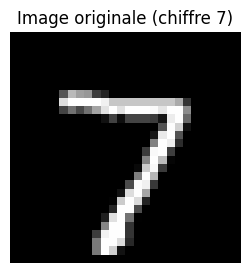

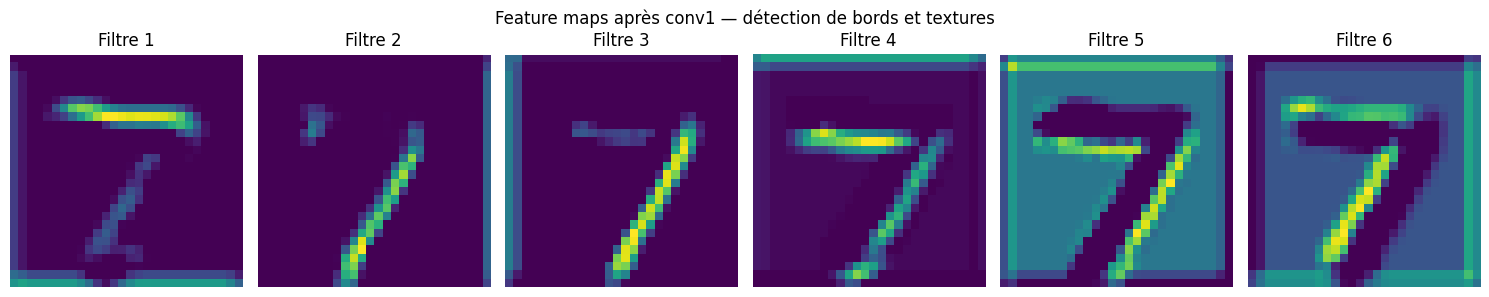

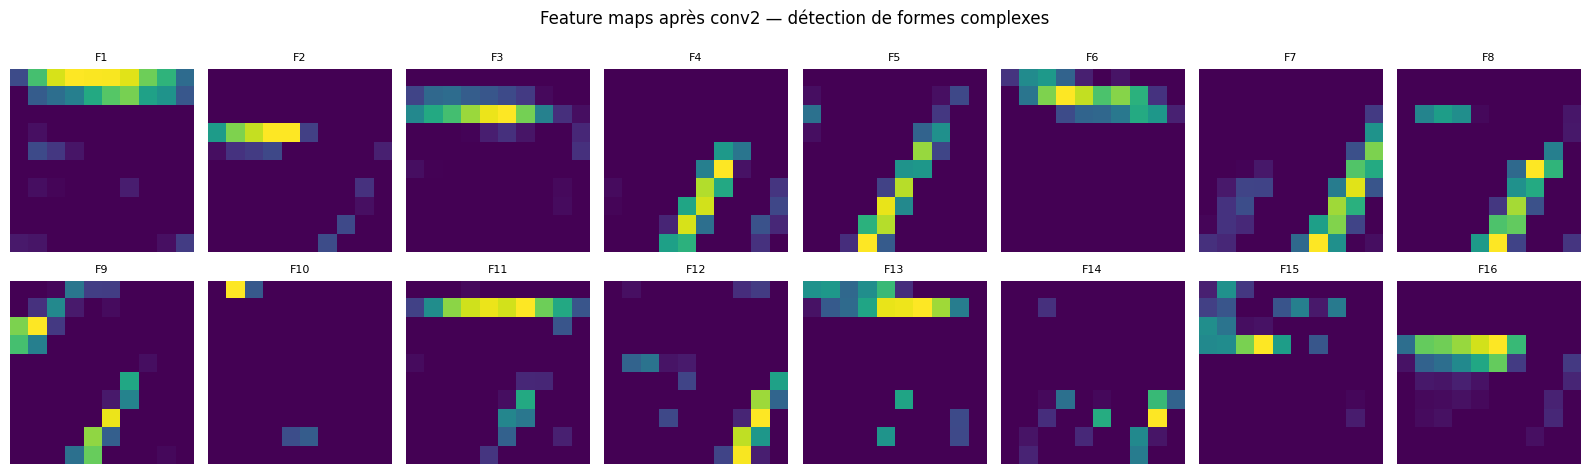

In [11]:
# ================================================================
# VISUALISATION DES FEATURE MAPS (sur LeNet)
# ================================================================
model_lenet = resultats_cnn['LeNet']['model']
model_lenet.eval()
sample_img, sample_lbl = next(iter(testloader))
sample_img = sample_img[0].unsqueeze(0).to(device)

# Image originale
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(sample_img.squeeze().cpu().numpy(), cmap='gray')
ax.set_title(f'Image originale (chiffre {sample_lbl[0].item()})')
ax.axis('off'); plt.show()

# Feature maps après conv1
with torch.no_grad():
    fm1 = torch.relu(model_lenet.conv1(sample_img))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(fm1[0,i].cpu().numpy(), cmap='viridis')
    axes[i].set_title(f'Filtre {i+1}'); axes[i].axis('off')
plt.suptitle('Feature maps après conv1 — détection de bords et textures')
plt.tight_layout(); plt.show()

# Feature maps après conv2
with torch.no_grad():
    x_tmp = model_lenet.pool(torch.relu(model_lenet.conv1(sample_img)))
    fm2   = torch.relu(model_lenet.conv2(x_tmp))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(fm2[0,i].cpu().numpy(), cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=8); ax.axis('off')
plt.suptitle('Feature maps après conv2 — détection de formes complexes')
plt.tight_layout(); plt.show()

### Interprétation des feature maps

**Après conv1 (6 filtres, 28×28) :**
- Zones lumineuses = régions où le filtre détecte un motif
- Certains filtres répondent aux **contours verticaux**, d'autres aux **contours horizontaux**
- Taille 28×28 préservée grâce au padding=2

**Après conv2 (16 filtres, 10×10) :**
- Représentation plus **abstraite** — formes complexes, combinaisons de motifs
- Certaines feature maps quasi nulles → ces filtres ne répondent pas à cette image
- **Hiérarchie** : conv1 = bas niveau (bords), conv2 = niveau intermédiaire (formes)

**Conclusion :** Le CNN apprend automatiquement une hiérarchie de représentations. Les architectures dérivées (AlexNet, VGG) approfondissent cette hiérarchie avec plus de couches et de filtres.

---
##  Étape II.9 — Comparaison MLP vs CNN vs dérivés

=== Comparaison finale MLP vs CNN vs Dérivés ===
Modèle                 Paramètres     Test Accuracy
----------------------------------------------------
MLP                    235,146        97.45%
LeNet                  61,706         98.89%
AlexNet simplifié      1,701,322      99.30%
VGG simplifié          870,634        99.28%


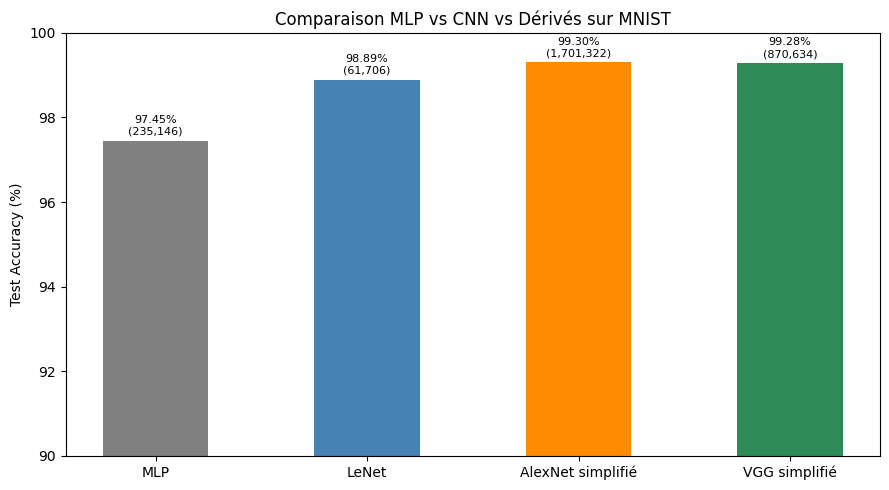

In [12]:
# ================================================================
# MLP SUR MNIST POUR COMPARAISON
# ================================================================
class MLPImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


model_mlp = MLPImage().to(device)
opt_mlp   = optim.Adam(model_mlp.parameters(), lr=0.001)
crit_mlp  = nn.CrossEntropyLoss()

for epoch in range(5):
    model_mlp.train()
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        opt_mlp.zero_grad()
        loss = crit_mlp(model_mlp(images), labels)
        loss.backward(); opt_mlp.step()

mlp_acc = evaluate_accuracy(model_mlp, testloader, device)
mlp_par = sum(p.numel() for p in model_mlp.parameters())

# Tableau final
print('=== Comparaison finale MLP vs CNN vs Dérivés ===')
print(f'{"Modèle":<22} {"Paramètres":<14} {"Test Accuracy"}')
print('-' * 52)
print(f'{"MLP":<22} {mlp_par:<14,} {mlp_acc:.2f}%')
for nom, res in resultats_cnn.items():
    print(f'{nom:<22} {res["params"]:<14,} {res["test_acc"]:.2f}%')

# Graphe comparatif
tous_noms   = ['MLP'] + list(resultats_cnn.keys())
tous_accs   = [mlp_acc] + [res['test_acc'] for res in resultats_cnn.values()]
tous_params = [mlp_par] + [res['params']   for res in resultats_cnn.values()]
couleurs_bar= ['gray', 'steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tous_noms, tous_accs, color=couleurs_bar, width=0.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparaison MLP vs CNN vs Dérivés sur MNIST')
ax.set_ylim(90, 100)
for bar, p in zip(bars, tous_params):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%\n({p:,})',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()